In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [26]:
DATA_DIR = Path("../data/raw/")
DATA_DIR.exists(), DATA_DIR

(True, WindowsPath('../data/raw'))

In [27]:
sorted([p.name for p in DATA_DIR.glob("*")])[:20]

['Damage Propagation Modeling.pdf',
 'RUL_FD001.txt',
 'RUL_FD002.txt',
 'RUL_FD003.txt',
 'RUL_FD004.txt',
 'readme.txt',
 'test_FD001.txt',
 'test_FD002.txt',
 'test_FD003.txt',
 'test_FD004.txt',
 'train_FD001.txt',
 'train_FD002.txt',
 'train_FD003.txt',
 'train_FD004.txt']

In [28]:
train_path = DATA_DIR / "train_FD001.txt"
train_path.exists(), train_path

(True, WindowsPath('../data/raw/train_FD001.txt'))

In [29]:
df_raw = pd.read_csv(train_path, sep=r"\s+", header=None)
df_raw.shape, df_raw.head()

((20631, 26),
    0   1       2       3      4       5       6        7        8      9   \
 0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
 1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
 2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
 3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
 4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   
 
    ...      16       17       18      19    20   21    22     23     24  \
 0  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06   
 1  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0  39.00   
 2  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0  38.95   
 3  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0  38.88   
 4  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0  38.90   
 
         25  
 0  23.4190  
 1  23.4236  
 2  23.3442  
 3

In [30]:
col_names = (["engine_id", "cycle"] + [f"op_setting_{i}" for i in range(1, 4)] + [f"sensor_{i}" for i in range(1, 22)])

In [31]:
df_raw = df_raw.iloc[:, :len(col_names)]
df_raw.columns = col_names

df_raw.head(), df_raw.shape

(   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
 0          1      1       -0.0007       -0.0004         100.0    518.67   
 1          1      2        0.0019       -0.0003         100.0    518.67   
 2          1      3       -0.0043        0.0003         100.0    518.67   
 3          1      4        0.0007        0.0000         100.0    518.67   
 4          1      5       -0.0019       -0.0002         100.0    518.67   
 
    sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
 0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
 1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
 2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
 3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
 4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   
 
    sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
 0    8138.62     8.4195      

In [32]:
print("Engines", df_raw["engine_id"].nunique())
print("Cycle range:", df_raw["cycle"].min(), "to", df_raw["cycle"].max())
df_raw.isna().sum().head()

Engines 100
Cycle range: 1 to 362


engine_id       0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
dtype: int64

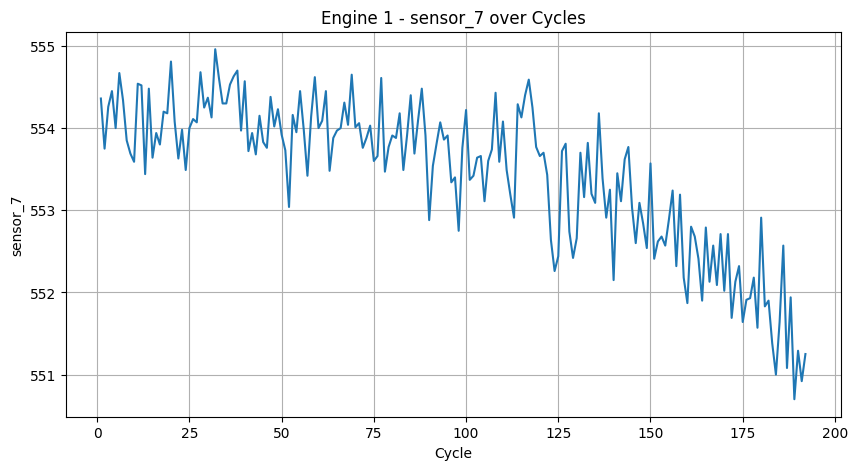

In [46]:
engine = 1
sensor = "sensor_7"

df_e = df_raw[df_raw["engine_id"] == engine]. sort_values("cycle")
plt.figure(figsize=(10, 5))
plt.plot(df_e["cycle"], df_e[sensor])
plt.title(f"Engine {engine} - {sensor} over Cycles")
plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.grid(True)
plt.show()

In [47]:
print("Shape:1", df_raw.shape)
print ("\nFirst 5 rows:")
display(df_raw.head())

print("\nColumns:")
print(df_raw.columns.tolist())

Shape:1 (20631, 26)

First 5 rows:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



Columns:
['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
